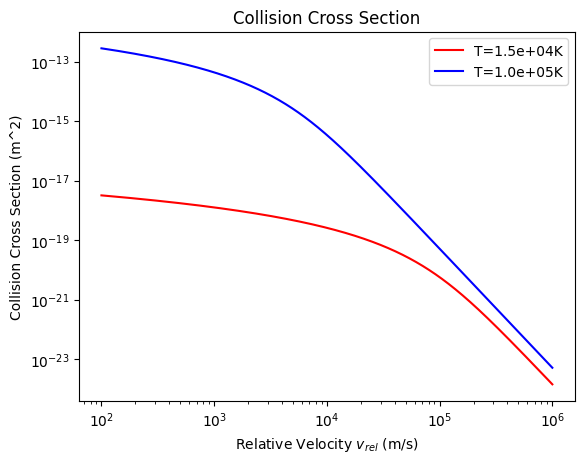

C:\Users\shaoq\AppData\Local\Temp\ipykernel_68\1818169709.py:69: ComplexWarning: Casting complex values to real discards the imaginary part
  farr[:,i] = dp*collfreq
C:\Users\shaoq\AppData\Local\Temp\ipykernel_68\1818169709.py:48: ComplexWarning: Casting complex values to real discards the imaginary part
  farr[:,i] = dp*collfreq


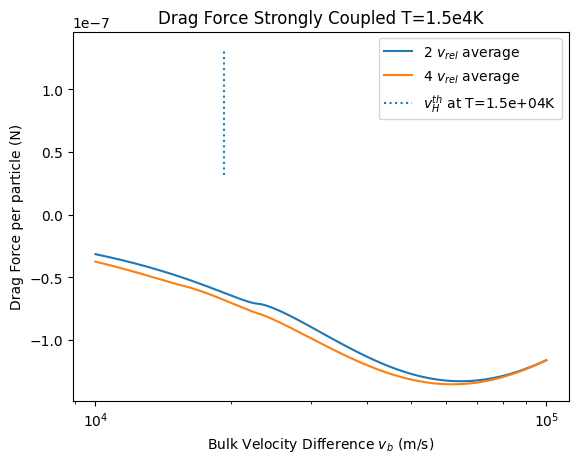

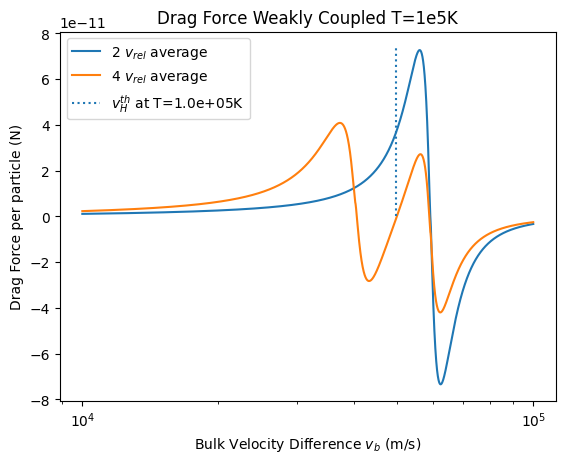

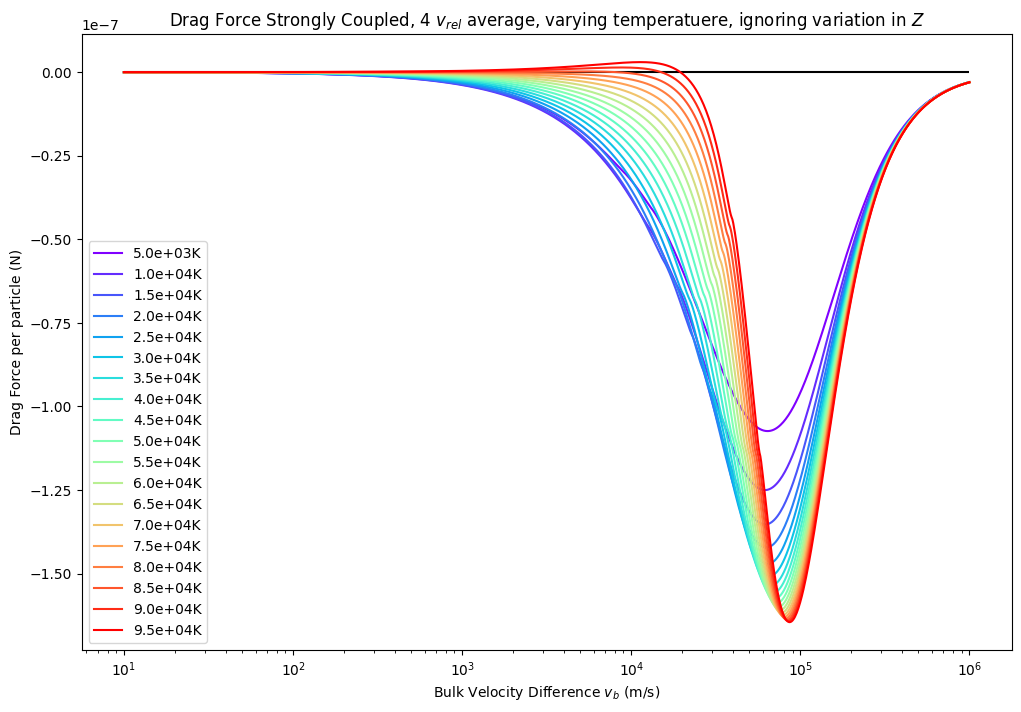

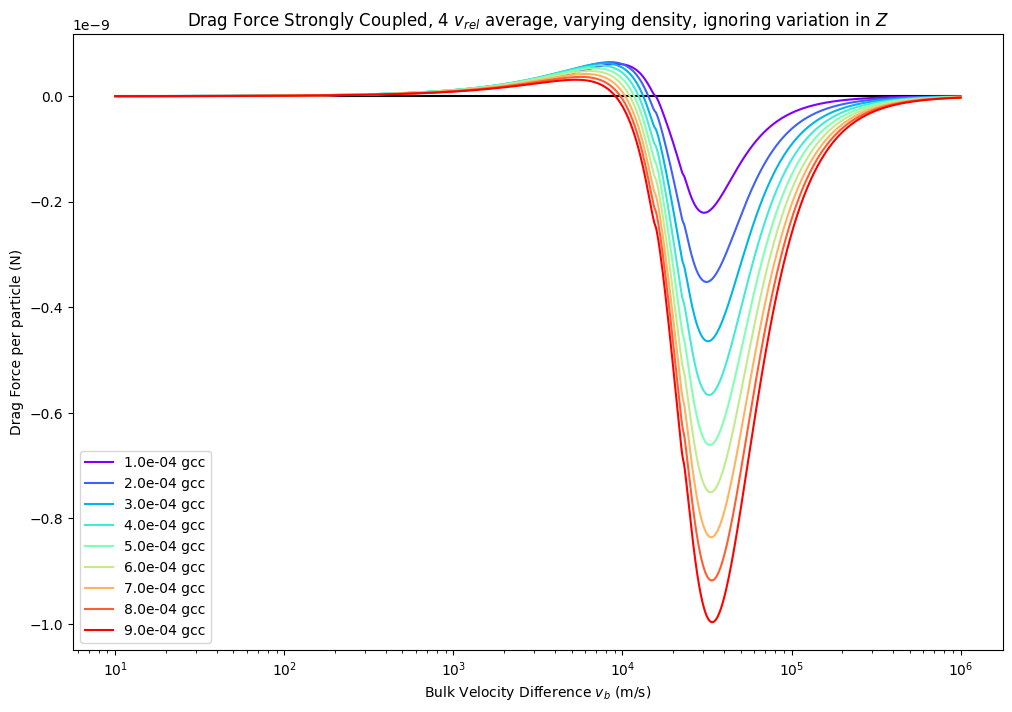

In [ ]:
import scipy as scp
import numpy as np
import math as math
import matplotlib.pyplot as plt
from matplotlib import cm
NA = 6.022e23
pi = 3.1415926535
me = 9.11e-31 #electron mass
ms = 28.0855*0.001/NA
mh = 1.008*0.001/NA
mu = ms*mh/(ms+mh)
qe = 1.6e-19
hbar = 6.626e-34
kb = 1.38e-23
e0 =  8.854e-12
#exp(-Ax)/x = B
#x = W(a/b)/a
def ccs2(vrel,vcom,T,gcc,z1=0.648,z2=3.84):# use kinetic energy difference
    ne =1e6* NA*z1*gcc/1.008
    ve = np.sqrt(3*kb*T/me)
    wp = np.sqrt(ne*(qe**2)/(me*e0))
    lD = ve/wp
    Tf = ((3*ne*(pi**2))**(2/3))*(hbar**2)/(2*me*kb)
    lS = lD*np.power(1+(2*Tf/(3*T)),1/4)
    k0 = 1/lS
    Aarr = (qe**2)*z1*z2/(4*pi*e0)
    #kinetic energy available is velocity relative to COM
    Barr = 0.5*mh*((vrel-vcom)**2)+0.5*ms*((vcom)**2)
    Carr = Barr/Aarr
    rc = scp.special.lambertw(k0/Carr)/k0
    return pi*rc**2

def FDtherm(vb,A,T,gcc,zh,zs):
    n =1e6* NA*gcc/1.008
    #Calculate vrel
    signarr1 = [1,1,-1,-1]
    signarr2 = [1,-1,1,-1]
    tss = np.sqrt(3*kb*T/ms)
    tsh = np.sqrt(3*kb*T/mh)
    farr = np.zeros((len(vb),4))
    for i in range(4):
        vrel = -vb + signarr1[i]*tsh + signarr2[i]*tss
        # print(vrel[-1])
        vcom = mh*vrel/(mh+ms)
        ccs = A*ccs2(vrel,vcom,T,gcc,zh,zs)
        # print(vcom[0])
        dp = 2*ms*vcom
        collfreq = n*ccs*np.abs(vrel)
        farr[:,i] = dp*collfreq
        # print(dp)
        # print(collfreq)
    return np.mean(farr,axis=1) #average over 4 vrel cases

def FD4(vb,A,T,gcc,zh,zs):
    n =1e6* NA*gcc/1.008
    #Calculate vrel
    signarr1 = [1,1,-1,-1]
    signarr2 = [1,-1,1,-1]
    tss = np.sqrt(3*kb*T/ms)
    tsh = np.sqrt(3*kb*T/mh)
    farr = np.zeros((len(vb),4))
    for i in range(4):
        vrel = -vb + signarr1[i]*tsh + signarr2[i]*tss
        # print(vrel[-1])
        vcom = mh*vrel/(mh+ms)
        ccs = A*ccs2(vrel,vcom,T,gcc,zh,zs)
        # print(vcom[0])
        dp = 2*ms*vcom
        collfreq = n*ccs*np.abs(vrel)
        farr[:,i] = dp*collfreq
        # print(dp)
        # print(collfreq)
    return np.mean(farr,axis=1) #average over 4 vrel cases

def FD2(vb,A,T,gcc,zh,zs):
    n =1e6* NA*gcc/1.008
    #Calculate vrel
    signarr1 = [1,-1]
    signarr2 = [1,-1]
    tss = np.sqrt(3*kb*T/ms)
    tsh = np.sqrt(3*kb*T/mh)
    farr = np.zeros((len(vb),2))
    for i in range(2):
        vrel = -vb + signarr1[i]*tsh + signarr2[i]*tss
        # print(vrel[-1])
        vcom = mh*vrel/(mh+ms)
        ccs = A*ccs2(vrel,vcom,T,gcc,zh,zs)
        # print(vcom[0])
        dp = 2*ms*vcom
        collfreq = n*ccs*np.abs(vrel)
        farr[:,i] = dp*collfreq
        # print(dp)
        # print(collfreq)
    return np.mean(farr,axis=1) #average over 4 vrel cases

plt.xlabel(r"Relative Velocity $v_{rel}$ (m/s)")
plt.ylabel("Collision Cross Section (m^2)")
plt.title("Collision Cross Section")
CD=1
Tarr = np.array([15000,100000])
gccarr = [1,1e-6]
zharr = [0.648,0.955]
zsarr = [3.84,4.91]
varr = np.logspace(4,5,10000)

varr3 = np.logspace(2,6,num=1000)
colors = ["red","blue"]
vtherm = np.sqrt(3*kb*Tarr/mh)
for i in range(len(Tarr)):
    T = Tarr[i]
    gcc = gccarr[i]
    zh=zharr[i]
    zs=zsarr[i]
    # print(np.min(dp(varr,T)))
    plt.plot(varr3,np.abs(ccs2(varr3,0,T,gcc,zh,zs)),label="T={:.1e}K".format(T),color=colors[i])
    # plt.vlines(vtherm[i],ymin=np.min(np.abs(FD(varr,CD,T,gcc,zh,zs))),ymax = np.max(np.abs(FD(varr,CD,T,gcc,zh,zs))),ls=":",label=r"$v_{{therm}}$ T={:.1e}K".format(T),color=colors[i])
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.show()


CD=1
vtherm = np.sqrt(3*kb*Tarr/mh)
titlearr = ["Drag Force Strongly Coupled T=1.5e4K","Drag Force Weakly Coupled T=1e5K"]
for i in range(len(Tarr)):
    plt.xlabel(r"Bulk Velocity Difference $v_b$ (m/s)")
    plt.ylabel("Drag Force per particle (N)")
    plt.title(titlearr[i])
    T = Tarr[i]
    gcc = gccarr[i]
    zh=zharr[i]
    zs=zsarr[i]
    # print(np.min(dp(varr,T)))
    force2 = FD2(varr,CD,T,gcc,zh,zs)
    force4 = FD4(varr,CD,T,gcc,zh,zs)
    plt.plot(varr,force2,label=r"2 $v_{rel}$ average")
    plt.plot(varr,force4,label=r"4 $v_{rel}$ average")
    plt.vlines(vtherm[i],ymin=np.min(np.abs(force2)),ymax = np.max(np.abs(force2)),ls=":",label=r"$v^{{th}}_H$ at T={:.1e}K".format(T))
    plt.xscale("log")
    plt.legend()
    plt.show()

varr = np.logspace(1,6,1000)

plt.figure(figsize=(12,8))
plt.hlines(y=0,xmin=np.min(varr),xmax=np.max(varr),color="black")

plt.xlabel(r"Bulk Velocity Difference $v_b$ (m/s)")
plt.ylabel("Drag Force per particle (N)")
plt.title("Drag Force Strongly Coupled, 4 $v_{rel}$ average, varying temperatuere, ignoring variation in $Z$")
Tarr2 = np.arange(5e3,1e5,5e3)
colors = cm.rainbow(np.linspace(0, 1, len(Tarr2)))
for i in range(len(Tarr2)):
    T = Tarr2[i]
    gcc = gccarr[0]
    zh=zharr[0]
    zs=zsarr[0]
    # print(np.min(dp(varr,T)))
    force2 = FD2(varr,CD,T,gcc,zh,zs)
    force4 = FD4(varr,CD,T,gcc,zh,zs)
    plt.plot(varr,force4,label="{:.1e}K".format(T),color=colors[i])
plt.xscale("log")
plt.legend()
plt.show()

varr = np.logspace(1,6,1000)
plt.figure(figsize=(12,8))
plt.hlines(y=0,xmin=np.min(varr),xmax=np.max(varr),color="black")
plt.xlabel(r"Bulk Velocity Difference $v_b$ (m/s)")
plt.ylabel("Drag Force per particle (N)")
plt.title("Drag Force Strongly Coupled, 4 $v_{rel}$ average, varying density, ignoring variation in $Z$")
gccarr2 = np.arange(1e-4,1e-3,1e-4)
# gccarr2 = np.array([1e0,1e-1,1e-2,1e-3,1e-4,1e-5])
colors = cm.rainbow(np.linspace(0, 1, len(gccarr2)))
for i in range(len(gccarr2)):
    T = Tarr[0]
    gcc = gccarr2[i]
    zh=zharr[0]
    zs=zsarr[0]
    # print(np.min(dp(varr,T)))
    force2 = FD2(varr,CD,T,gcc,zh,zs)
    force4 = FD4(varr,CD,T,gcc,zh,zs)
    plt.plot(varr,force4,label="{:.1e} gcc".format(gcc),color=colors[i])
plt.vlines(vtherm[0],ymin=np.min(force4),ymax = np.max(force4),color="black",ls=":",label=r"$v^{{th}}_H$ at T={:.1e}K".format(T))
# plt.yscale("log")
plt.xscale("log")
plt.legend()
plt.show()



# Drag Third Approx

C:\Users\shaoq\AppData\Local\Temp\ipykernel_14464\3160785502.py:101: ComplexWarning: Casting complex values to real discards the imaginary part
  result[i] = 2*mu*n*np.sum(ccs*vrel*np.abs(vrel)*frel(vrel,vb,T))/np.sum(frel(vrel,vb,T))
C:\Users\shaoq\AppData\Local\Temp\ipykernel_14464\3160785502.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  farr[:,i] = dp*collfreq
C:\Users\shaoq\AppData\Local\Temp\ipykernel_14464\3160785502.py:62: ComplexWarning: Casting complex values to real discards the imaginary part
  farr[:,i] = dp*collfreq


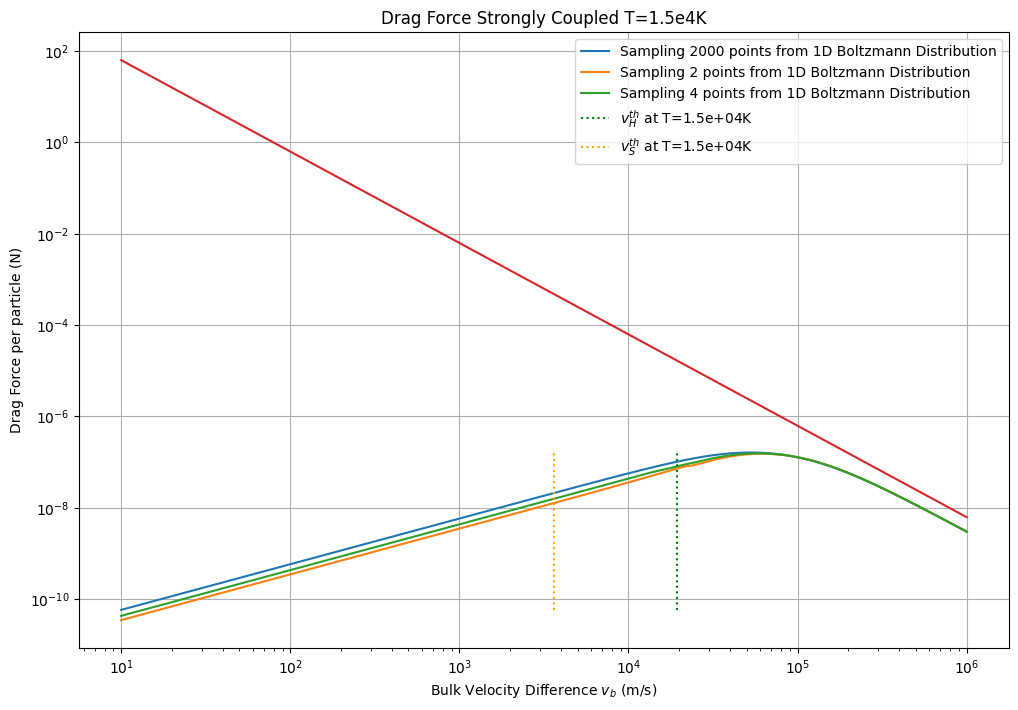

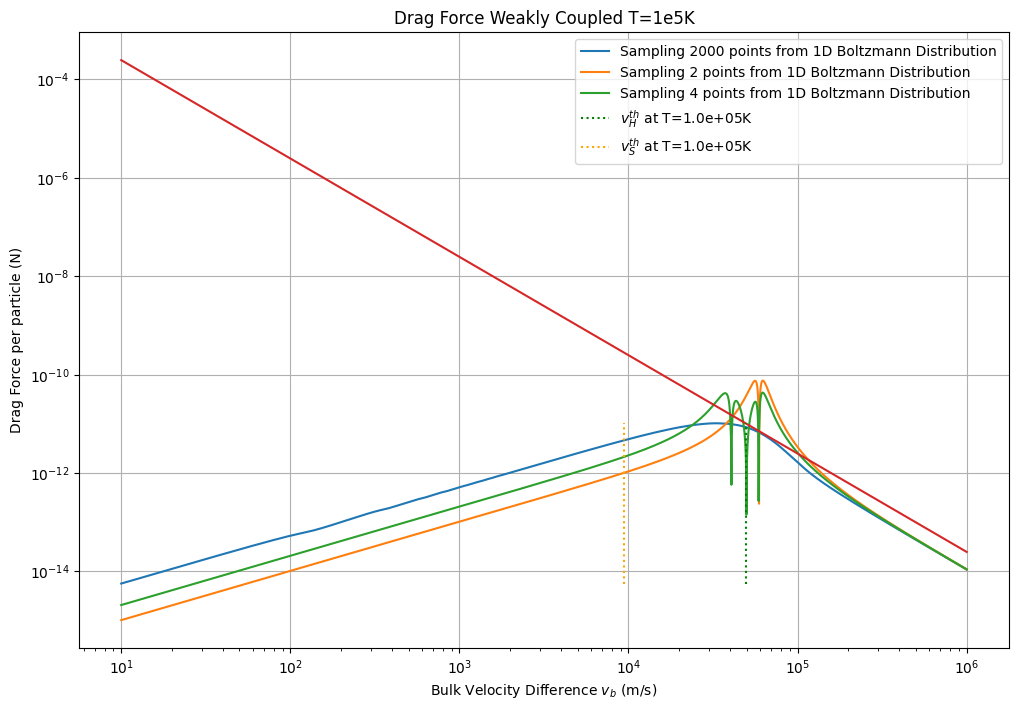

In [ ]:
import numpy as np
import scipy as scp
import numpy as np
import math as math
import matplotlib.pyplot as plt
from matplotlib import cm
NA = 6.022e23
pi = 3.1415926535
me = 9.11e-31 #electron mass
ms = 28.0855*0.001/NA
mh = 1.008*0.001/NA
mu = ms*mh/(ms+mh)
qe = 1.6e-19
hbar = 6.626e-34
kb = 1.38e-23
e0 =  8.854e-12
#exp(-Ax)/x = B
#x = W(a/b)/a
def ccs2(vrel,T,gcc,z1=0.648,z2=3.84):# use kinetic energy difference
    NA = 6.022e23
    pi = 3.1415926535
    me = 9.11e-31 #electron mass
    ms = 28.0855*0.001/NA
    mh = 1.008*0.001/NA
    mu = ms*mh/(ms+mh)
    qe = 1.6e-19
    hbar = 6.626e-34
    kb = 1.38e-23
    e0 =  8.854e-12
    vcom =  mh*vrel/(mh+ms)
    ne =1e6* NA*z1*gcc/1.008
    ve = np.sqrt(3*kb*T/me)
    wp = np.sqrt(ne*(qe**2)/(me*e0))
    lD = ve/wp
    Tf = ((3*ne*(pi**2))**(2/3))*(hbar**2)/(2*me*kb)
    lS = lD*np.power(1+(2*Tf/(3*T)),1/4)
    k0 = 1/lS
    Aarr = (qe**2)*z1*z2/(4*pi*e0)
    #kinetic energy available is velocity relative to COM
    Barr = 0.5*mh*((vrel-vcom)**2)+0.5*ms*((vcom)**2)
    Carr = Barr/Aarr
    rc = scp.special.lambertw(k0/Carr)/k0
    return pi*rc**2


def FD4(vb,A,T,gcc,zh,zs):
    n =1e6* NA*gcc/1.008
    #Calculate vrel
    signarr1 = [1,1,-1,-1]
    signarr2 = [1,-1,1,-1]
    tss = np.sqrt(3*kb*T/ms)
    tsh = np.sqrt(3*kb*T/mh)
    farr = np.zeros((len(vb),4))
    for i in range(4):
        vrel = -vb + signarr1[i]*tsh + signarr2[i]*tss
        # print(vrel[-1])
        vcom = mh*vrel/(mh+ms)
        ccs = A*ccs2(vrel,T,gcc,zh,zs)
        # print(vcom[0])
        dp = 2*ms*vcom
        collfreq = n*ccs*np.abs(vrel)
        farr[:,i] = dp*collfreq
        # print(dp)
        # print(collfreq)
    return np.mean(farr,axis=1) #average over 4 vrel cases

def FD2(vb,A,T,gcc,zh,zs):
    n =1e6* NA*gcc/1.008
    #Calculate vrel
    signarr1 = [1,-1]
    signarr2 = [1,-1]
    tss = np.sqrt(3*kb*T/ms)
    tsh = np.sqrt(3*kb*T/mh)
    farr = np.zeros((len(vb),2))
    for i in range(2):
        vrel = -vb + signarr1[i]*tsh + signarr2[i]*tss
        # print(vrel[-1])
        vcom = mh*vrel/(mh+ms)
        ccs = A*ccs2(vrel,T,gcc,zh,zs)
        # print(vcom[0])
        dp = 2*ms*vcom
        collfreq = n*ccs*np.abs(vrel)
        farr[:,i] = dp*collfreq
        # print(dp)
    return np.mean(farr,axis=1) #average over 4 vrel cases

def frel(vrel,vb,T):
    mu = ms*mh/(ms+mh)
    return np.sqrt(mu/(2*pi*kb*T))*np.exp(-mu*np.square(vrel-vb)/(2*kb*T))

def FDint(vbarr,A,T,gcc,zh,zs):
    mu = ms*mh/(ms+mh)
    n =1e6* NA*gcc/1.008
    std = np.sqrt(kb*T/mu)
    result = np.zeros(len(vbarr))
    for i in range(len(vbarr)):
        vb = vbarr[i]
        vrel = np.linspace(vb-8*std,vb+8*std,2000)
        dvrel = vrel[1]-vrel[0]
        ccs = A*ccs2(vrel,T,gcc,zh,zs)
        result[i] = 2*mu*n*np.sum(ccs*vrel*np.abs(vrel)*frel(vrel,vb,T))/np.sum(frel(vrel,vb,T))
    return result
def yukdv(vbarr,A,T,gcc,zh,zs):
    NA = 6.022e23
    pi = 3.1415926535
    me = 9.11e-31 #electron mass
    ms = 28.0855*0.001/NA
    mh = 1.008*0.001/NA
    mu = ms*mh/(ms+mh)
    qe = 1.6e-19
    hbar = 6.626e-34
    kb = 1.38e-23
    e0 =  8.854e-12
    n =1e6* NA*gcc/1.008
    std = np.sqrt(kb*T/mu)
    result = np.zeros(len(vbarr))
    for i in range(len(vbarr)):
        vb = vbarr[i]
        vrel = np.linspace(vb-8*std,vb+8*std,2000)
        dvrel = vrel[1]-vrel[0]
        ccs = A*ccs2(vrel,T,gcc,zh,zs)
        result[i] = 2*mu*np.sum(vrel*frel(vrel,vb,T))/np.sum(frel(vrel,vb,T))/ms
    return result

#Goldston and Rutherford
def grlambda(z1,z2,T,gcc):
    #use cgs for coulomb logarithm
    NA = 6.022e23
    pi = 3.1415926535
    me = 9.11e-31*1000 #electron mass
    ms = 28.0855/NA
    mh = 1.008/NA
    mu = ms*mh/(ms+mh)
    qe =  4.8032047e-10#cgs
    kb = 1.380649e-16 #cgs units
    return (1.5/(z1*z2*(qe**3)))*((kb**3)*(T**3)/(pi*z1*gcc/(mh)))**0.5

def grdrag(w,z1,z2,T,gcc):
    #use SI units for goldstone rutherford drag
    #Goldston and Rutherford use SI
    NA = 6.022e23
    pi = 3.1415926535
    me = 9.11e-31 #electron mass
    ms = 28.0855*0.001/NA
    mh = 1.008*0.001/NA
    e0 = 8.8541878188e-12
    qe = 1.602176634e-19
    return ms*(1e6*0.001*gcc/mh)*(z1**2)*(z2**2)*(qe**4)*np.log(grlambda(z1,z2,T,gcc))/(4*pi*(e0**2)*ms*mh*np.square(w))


CD=1
Tarr = np.array([15000,100000])
gccarr = [1,1e-6]
zharr = [0.648,0.955]
zsarr = [3.84,4.91]
varr = np.logspace(1,6,10000)


CD=1
vthermh = np.sqrt(3*kb*Tarr/mh)
vtherms = np.sqrt(3*kb*Tarr/ms)
titlearr = ["Drag Force Strongly Coupled T=1.5e4K","Drag Force Weakly Coupled T=1e5K"]
for i in range(len(Tarr)):
    plt.figure(figsize=(12,8))
    plt.xlabel(r"Bulk Velocity Difference $v_b$ (m/s)")
    plt.ylabel("Drag Force per particle (N)")
    plt.title(titlearr[i])
    T = Tarr[i]
    gcc = gccarr[i]
    zh=zharr[i]
    zs=zsarr[i]
    # print(np.min(dp(varr,T)))
    force2 = FDint(varr,CD,T,gcc,zh,zs)
    force3 = FD2(varr,CD,T,gcc,zh,zs)
    force4 = FD4(varr,CD,T,gcc,zh,zs)
    plt.plot(varr,np.abs(force2),label=r"Sampling 2000 points from 1D Boltzmann Distribution")
    plt.plot(varr,np.abs(force3),label=r"Sampling 2 points from 1D Boltzmann Distribution")
    plt.plot(varr,np.abs(force4),label=r"Sampling 4 points from 1D Boltzmann Distribution")
    plt.plot(varr,np.abs(grdrag(varr,zh,zs,T,gcc)),label="Goldston and Rutherford")

    plt.vlines(vthermh[i],ymin=np.min(np.abs(force2)),ymax = np.max(np.abs(force2)),ls=":",label=r"$v^{{th}}_H$ at T={:.1e}K".format(T),color="green")
    plt.vlines(vtherms[i],ymin=np.min(np.abs(force2)),ymax = np.max(np.abs(force2)),ls=":",label=r"$v^{{th}}_S$ at T={:.1e}K".format(T),color="orange")
    plt.xscale("log")
    plt.yscale("log")
    plt.grid()
    plt.legend()
    plt.show()



# Intro to Plasma Physics

-4.219830254206695


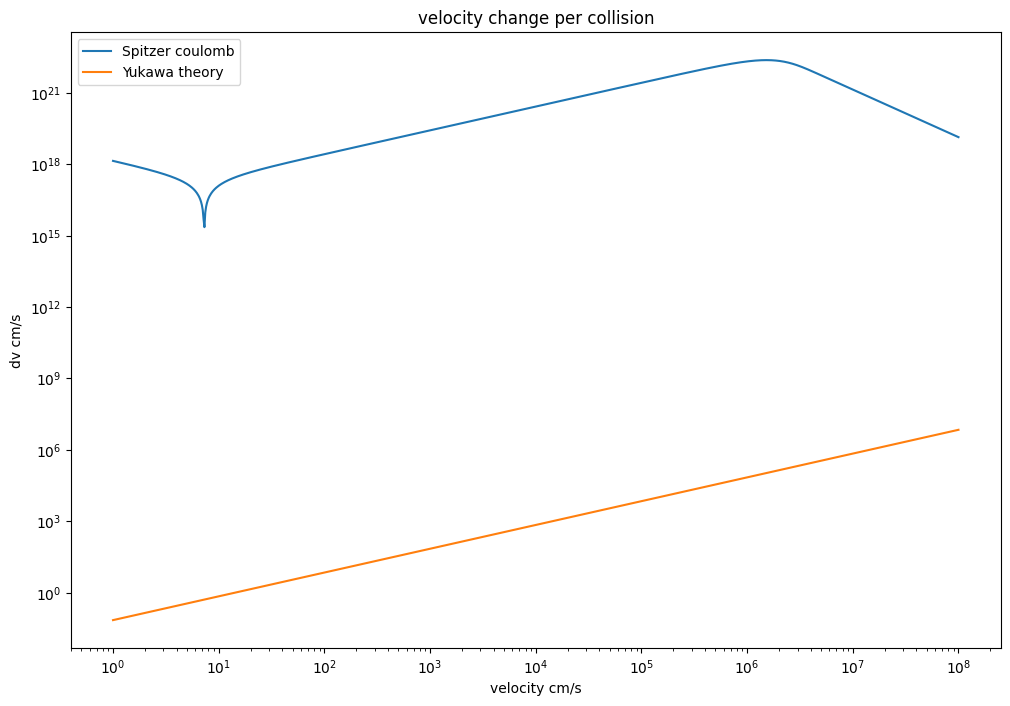

In [24]:
import numpy as np
import scipy as scp
import numpy as np
import math as math
import matplotlib.pyplot as plt
from matplotlib import cm


#Coulomb collision Lyman Spitzer
def cLambda(z1,z2,T,gcc):
    #use cgs units
    NA = 6.022e23
    pi = 3.1415926535
    me = 9.11e-31*1000 #electron mass
    ms = 28.0855/NA
    mh = 1.008/NA
    mu = ms*mh/(ms+mh)
    qe =  4.8032047e-10#cgs
    kb = 1.380649e-16 #cgs units
    return (1.5/(z1*z2*(qe**3)))*((kb**3)*(T**3)/(pi*z1*gcc/(mh)))**0.5

def cG(x):
    return (scp.special.erf(x) - x*(2/np.sqrt(pi))*np.exp(-x**2))/(2*np.square(x))

def cAD(z1,z2,T,gcc):
    #use cgs units
    NA = 6.022e23
    pi = 3.1415926535
    me = 9.11e-31*1000 #electron mass
    ms = 28.0855/NA
    mh = 1.008/NA
    mu = ms*mh/(ms+mh)
    qe =  4.8032047e-10#cgs
    kb = 1.380649e-16 #cgs units
    print(np.log(cLambda(z1,z2,T,gcc)))
    return 8*pi*(qe**4)*(gcc/mh)*(z1**2)*(z2**2)*np.log(cLambda(z1,z2,T,gcc))/(ms**2)
def cdv(w,z1,z2,T,gcc): #returns dv in cm/s
    #use cgs units
    NA = 6.022e23
    pi = 3.1415926535
    me = 9.11e-31*1000 #electron mass
    ms = 28.0855/NA
    mh = 1.008/NA
    mu = ms*mh/(ms+mh)
    qe =  4.8032047e-10#cgs
    kb = 1.380649e-16 #cgs units
    l = np.sqrt(mh/(2*kb*T))
    return cAD(z1,z2,T,gcc)*(l**2)*(1+ms/mh)*cG(l*w)
warr = np.logspace(0,8,1000)

z1arr = [0.648,0.955]
z2arr = [3.84,4.91]
gccarr = [1.0,1e-6]
Tarr = [15000,100000]

i=0
plt.figure(figsize=(12,8))
plt.plot(warr,np.abs(cdv(warr,z1arr[i],z2arr[i],Tarr[i],gccarr[i])),label="Spitzer coulomb")
plt.title("velocity change per collision")
A=0
plt.plot(warr,100*yukdv(warr/100,A,Tarr[i],gccarr[i],z1arr[i],z2arr[i]),label="Yukawa theory")
plt.legend()
plt.xscale("log")
plt.xlabel("velocity cm/s")
plt.ylabel("dv cm/s")
plt.yscale("log")




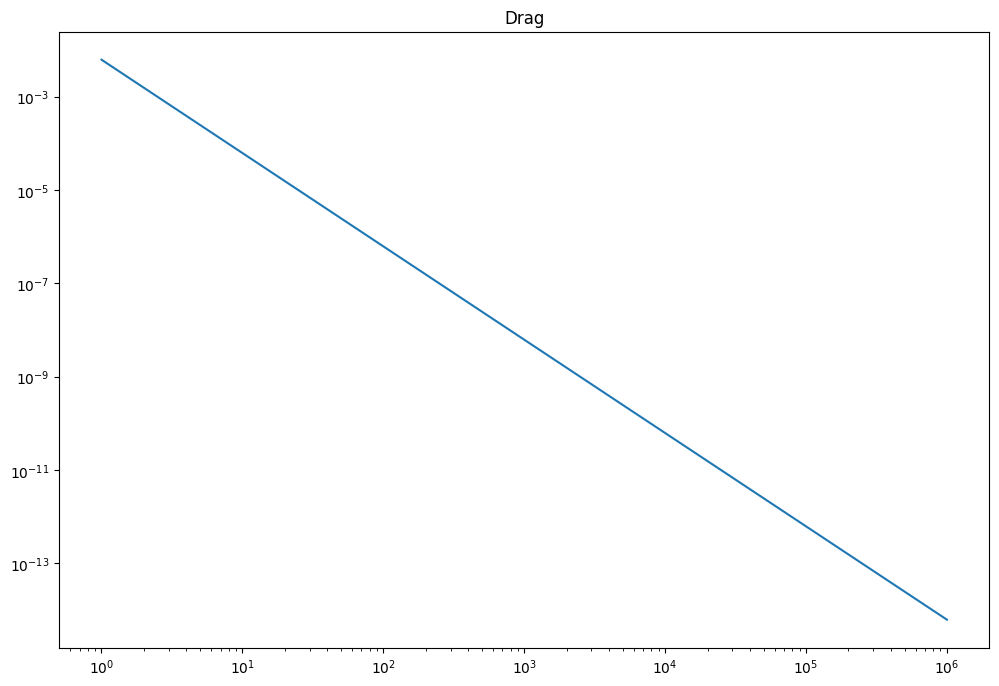

In [ ]:
import numpy as np
import scipy as scp
import numpy as np
import math as math
import matplotlib.pyplot as plt
from matplotlib import cm

"""
J^2*s^2/(kg^2*m^3)
J^2/(N^2*m*s^2)
J^2*m/(J^2*s^2)
m/(s^2)

"""

#Goldston and Rutherford
def grlambda(z1,z2,T,gcc):
    #use cgs for coulomb logarithm
    NA = 6.022e23
    pi = 3.1415926535
    me = 9.11e-31*1000 #electron mass
    ms = 28.0855/NA
    mh = 1.008/NA
    mu = ms*mh/(ms+mh)
    qe =  4.8032047e-10#cgs
    kb = 1.380649e-16 #cgs units
    return (1.5/(z1*z2*(qe**3)))*((kb**3)*(T**3)/(pi*z1*gcc/(mh)))**0.5

def grdrag(w,z1,z2,T,gcc):
    #use SI units for goldstone rutherford drag
    #Goldston and Rutherford use SI
    NA = 6.022e23
    pi = 3.1415926535
    me = 9.11e-31 #electron mass
    ms = 28.0855*0.001/NA
    mh = 1.008*0.001/NA
    e0 = 8.8541878188e-12
    qe = 1.602176634e-19
    return ms*(0.001*gcc/mh)*(z1**2)*(z2**2)*(qe**4)*np.log(grlambda(z1,z2,T,gcc))/(4*pi*(e0**2)*ms*mh*np.square(w))

warr = np.logspace(0,6,1000)

z1arr = [0.648,0.955]
z2arr = [3.84,4.91]
gccarr = [1.0,1e-6]
Tarr = [15000,100000]

#only strongly coupled case makes sense
i=0
plt.figure(figsize=(12,8))
plt.title("Drag")
plt.plot(warr,np.abs(grdrag(warr,z1arr[i],z2arr[i],Tarr[i],gccarr[i])))
plt.xscale("log")
plt.yscale("log")





# Fit Low and High velocity Behavior

C:\Users\shaoq\AppData\Local\Temp\ipykernel_19216\228009934.py:91: ComplexWarning: Casting complex values to real discards the imaginary part
  result[i] = 2*mu*n*dvrel*np.sum(ccs*np.abs(vrel)*vrel*frel(vrel,vb,T))


9787
10000


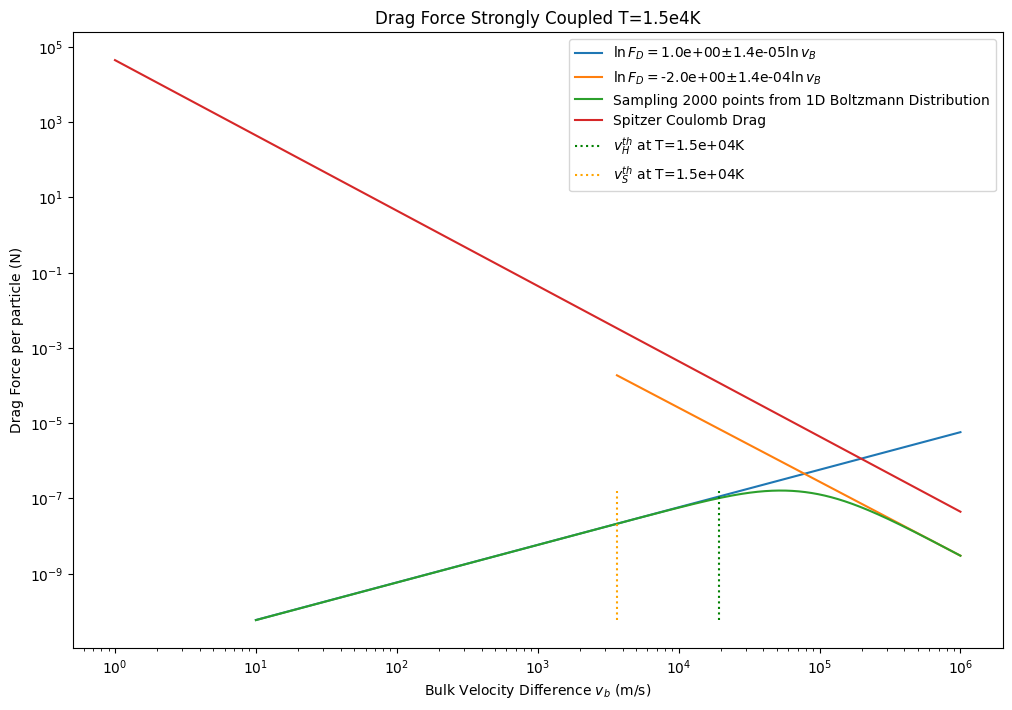

8579
10000


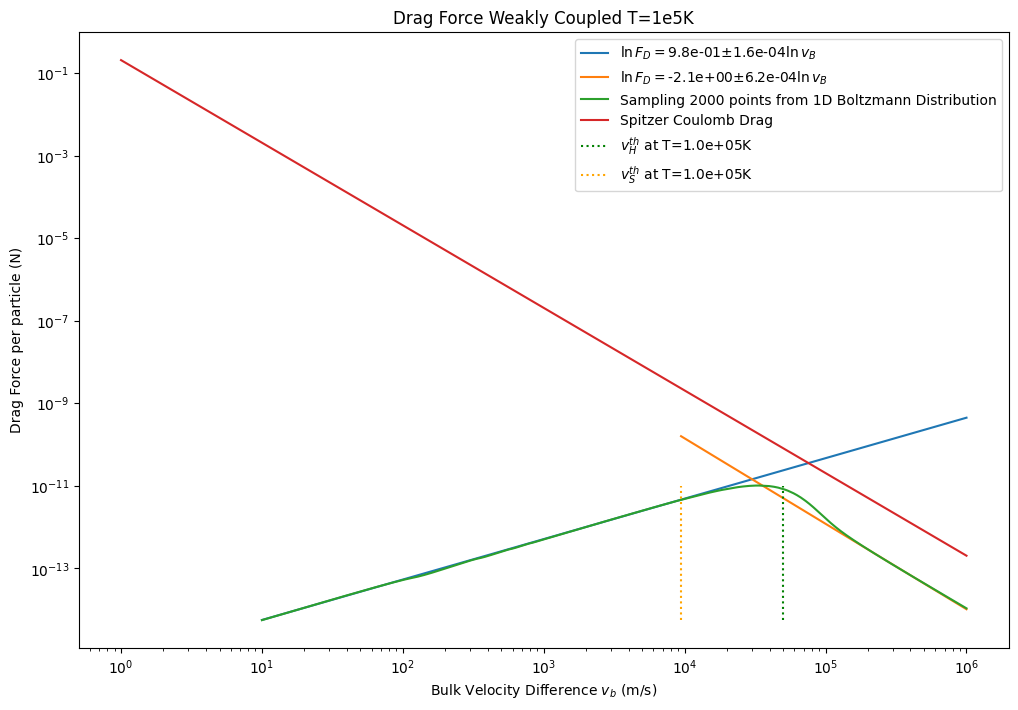

In [17]:
import numpy as np
import scipy as scp
import numpy as np
import math as math
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.optimize import curve_fit
CD=1
Tarr = np.array([15000,100000])
gccarr = [1,1e-6]
zharr = [0.648,0.955]
zsarr = [3.84,4.91]
varr = np.logspace(1,6,1000)
vthermh = np.sqrt(3*kb*Tarr/mh)
vtherms = np.sqrt(3*kb*Tarr/ms)
titlearr = ["Drag Force Strongly Coupled T=1.5e4K","Drag Force Weakly Coupled T=1e5K"]


def pow(x,A,n):
    return A*np.power(x,n)
for i in range(len(Tarr)):
    plt.figure(figsize=(12,8))
    plt.xlabel(r"Bulk Velocity Difference $v_b$ (m/s)")
    plt.ylabel("Drag Force per particle (N)")
    plt.title(titlearr[i])
    T = Tarr[i]
    gcc = gccarr[i]
    zh=zharr[i]
    zs=zsarr[i]
    # print(np.min(dp(varr,T)))
    force2 = FDint(varr,CD,T,gcc,zh,zs)
    lowlim = np.argmin(np.abs(varr-vtherms[i]))
    highlim = lowlim+np.argmin(np.abs(force2[lowlim:]-0.03*np.max(force2)))
    print(highlim)
    print(len(force2))
    A0 = np.max(force2)/varr[np.argmax(force2)]
    lopt,lcov = curve_fit(pow,varr[:lowlim],force2[:lowlim],[A0,1])
    lerr = np.sqrt(np.diag(lcov))
    plt.plot(varr,pow(varr,*lopt),label=r"$\ln F_D = ${:.1e}$\pm${:.1e}$\ln v_B$".format(lopt[1],lerr[1]))
    A0 = force2[-1]*(varr[-1]**2)
    hopt,hcov = curve_fit(pow,varr[highlim:],force2[highlim:],[A0,-2])
    herr = np.sqrt(np.diag(hcov))
    plt.plot(varr[lowlim:],pow(varr[lowlim:],*hopt),label=r"$\ln F_D = ${:.1e}$\pm${:.1e}$\ln v_B$".format(hopt[1],herr[1]))
    plt.plot(varr,force2,label=r"Sampling 2000 points from 1D Boltzmann Distribution")
    plt.plot(warr,cdrag(warr,zh,zs,T,gcc),label=r"Spitzer Coulomb Drag")

    plt.vlines(vthermh[i],ymin=np.min(np.abs(force2)),ymax = np.max(np.abs(force2)),ls=":",label=r"$v^{{th}}_H$ at T={:.1e}K".format(T),color="green")
    plt.vlines(vtherms[i],ymin=np.min(np.abs(force2)),ymax = np.max(np.abs(force2)),ls=":",label=r"$v^{{th}}_S$ at T={:.1e}K".format(T),color="orange")
    plt.xscale("log")
    plt.yscale("log")
    plt.legend()
    plt.show()



# Stopping Distance

In [36]:
import numpy as np
import pandas as pd
Temp = np.arange(5e3,1e5+1,5e3)
rho = np.arange(0,-11,-1,dtype=np.float64)
rho = np.power(10,rho)
data = np.zeros((len(Temp)*len(rho),2))
rlen = len(rho)
for i in range(len(Temp)):
    for j in range(len(rho)):
        data[rlen*i+j,0] = Temp[i]
        data[rlen*i+j,1] = rho[j]
df = pd.DataFrame(data,columns=["Temp (K)","rho (gcc)"])
df.to_csv("temprhogrid.csv")